# 配置项

In [1]:
# # 
# import json
# import os
# os.environ["ENV_VERSION"]="uat"
# import dolphindb as ddb
# import pandas as pd
# import os
# # os.system("rm -rf /tmp")
# from AutoMiningFrame.configs.local_connect import parse_connect
# file_path = "/data/user/quanttest007/016869/DolphindbFactors/StockMMNormAllFactors/"
# non_factor_path = "/data/user/quanttest007/016869/DolphindbFactors/StockMMNormAllNonFactors/"
# start_date = '20240612'
# end_date = '20240612'
# target_securities = ['688012.SH']

# factor_names = 'FactorVixUp_n_tick40'
# from AutoMiningFrame.DataCaculation.entry.FactorManager import FactorProvider
# user_id='016869'
# fd = FactorProvider(user_id)

# Dolphindb 流式结果

In [2]:

# factor_module_name = file_path.split("/")[-2]
# nonfactor_module_name = non_factor_path.split("/")[-2]
# nonfactor_dos_name = [i[:-4] for i in os.listdir(non_factor_path) if i.endswith(".dos")]
# if os.path.exists("/home/appadmin/server/modules/Factors"):
#     print("/home/appadmin/server/modules/Factors 目录已存在，正在删除")
#     os.system("rm -r /home/appadmin/server/modules/Factors")
# if os.path.exists("/home/appadmin/server/modules/NoneFactor"):
#     print("/home/appadmin/server/modules/NoneFactor 目录已存在，正在删除")
#     os.system("rm -r /home/appadmin/server/modules/NoneFactor")
# os.system("cp -r {} /home/appadmin/server/modules/Factors".format(file_path))
# os.system("cp -r {} /home/appadmin/server/modules/NoneFactor".format(non_factor_path))

# dol_start_date = start_date[:4] + "." + start_date[4:6] + "." + start_date[6:]
# dol_end_date = end_date[:4] + "." + end_date[4:6] + "." + end_date[6:]
# s = ddb.session()
# host, port, userid, password = parse_connect()
# print(host,port,userid,password)
# s.connect(host=host, port=port, userid=userid, password=password)
# scripts = f"""
#     undef all
#     go
#     Path_noneFactor = "{non_factor_path}"
#     Path_Factors =  "{file_path}"
#     factorNamesConfig=['{factor_names}']
#     use ta
#     use DolphinFrame::DataManager    
#     /**==============noneFactor=================*/
#     noneFactorNames = exec filename from files(Path_noneFactor) where filename != ".gitkeep"
#     if (noneFactorNames.size() != 0){{
#     for(noneFac in {nonfactor_dos_name}){{runScript("use NoneFactor::" + noneFac)}}
#     }}
#     /**==============Òò×ÓÏà¹Ø²ÎÊý=================*/
#     factorNames = factorNamesConfig
#     for (fac in factorNames) runScript("use Factors::" + fac)
    
#     def regexFactorNameOfDefAndReturn(Path_Factors, factorName){{
#         pathFactor = Path_Factors + factorName + ".dos"
#         factorTxt = file(pathFactor)
#         lines = factorTxt.readLines()
#         factorTxt.close()
#         txt = ""
#         for (line in lines){{
#             txt += line
#             }}
#         a = txt.regexFind("def")
#         b = txt.regexFind("\\\\{{")
#         factorDef = txt[(a+4):b]
#         c = txt.regexFind("return")
#         d = txt.regexFind("\\\\}}", c)
#         factorReturn = txt[(c+7):d]
#         return factorDef, factorReturn
#         }}
    
#     factorsDef = []
#     factorsReturn = []
#     for (factorName in factorNames){{
#         D, R = regexFactorNameOfDefAndReturn(Path_Factors, factorName)
#         factorsDef.append!(D)
#         if(R.like("%,%")){{
#             RList = R.split(",")
#             for (r in RList) factorsReturn.append!(regexReplace(r,'\\\\s',''))
#             }}
#         else{{
#             factorsReturn.append!(regexReplace(R,'\\\\s',''))
#             }}
#         }}
    
#     factorsDefConcat = ""
#     for (x in factorsDef) factorsDefConcat += x + ","
#     factorsDefConcat = factorsDefConcat[:factorsDefConcat.strlen()-1]
#     script = "metrics = <[concatDateTime(M_MDDate, M_MDTime), " + factorsDefConcat + "]>"
#     runScript(script)
#     go
#     /**=============»Ø·Å¼ÆËãÒò×Ó===============*/
#     enhancedTickData = getMarketData_Remote(stock={target_securities}, startTime={dol_start_date}, endTime={dol_end_date}, 
#                                             tableName=`sh_stock_tick_l2p_persec)
    
#     names = `M_ReceiveDateTime`M_MDDate`M_HTSCSecurityID`M_MDTime`M_SecurityType`M_SecuritySubType`M_SecurityID`M_SecurityIDSource`M_Symbol`M_TradingPhaseCode`M_PreClosePx`M_NumTrades`M_TotalVolumeTrade`M_TotalValueTrade`M_LastPx`M_OpenPx`M_ClosePx`M_HighPx`M_LowPx`M_DiffPx1`M_DiffPx2`M_MaxPx`M_MinPx`M_TotalBidQty`M_TotalOfferQty`M_WeightedAvgBidPx`M_WeightedAvgOfferPx`M_AfterHoursNumTrades`M_AfterHoursTotalVolumeTrade`M_AfterHoursTotalValueTrade`M_Buy1NoOrders`M_Buy1OrderDetail`M_Sell1NoOrders`M_Sell1OrderDetail`M_TradeMDTime`M_TradeIndex`M_TradeType`M_TradePrice`M_TradeQty`M_TradeBSFlag`M_TradeBuyNo`M_TradeSellNo`M_ApplSeqNum`M_TradeMoney`M_BuyQty`M_BuyMoney`M_BuyCount`M_SellQty`M_SellMoney`M_SellCount`M_BuyPrice`M_BuyOrderQty`M_BuyNumOrders`M_SellPrice`M_SellOrderQty`M_SellNumOrders
#     types = ["TIMESTAMP","DATE","SYMBOL","TIME","INT","STRING","STRING","INT","STRING","STRING","DOUBLE","LONG","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","DOUBLE","STRING","DOUBLE","STRING","TIME[]","LONG[]","LONG[]","DOUBLE[]","DOUBLE[]","LONG[]","LONG[]","LONG[]","LONG[]","DOUBLE[]","DOUBLE","DOUBLE","INT","DOUBLE","DOUBLE","INT","DOUBLE[]","DOUBLE[]","DOUBLE[]","DOUBLE[]","DOUBLE[]","DOUBLE[]"]
#     sch = table(names as name, types as type)
        
#     rseEngineOutput = table(500000:0, `HTSCSecurityID`timestamp join factorsReturn, [SYMBOL, TIMESTAMP] join take(DOUBLE, factorsReturn.size()))
#     try{{dropStreamEngine("rseEngine")}} catch(ex){{ print(ex) }}
#     rse = createReactiveStateEngine(name = "rseEngine", metrics = metrics, dummyTable = enhancedTickData, outputTable = rseEngineOutput, keyColumn=`M_HTSCSecurityID, keepOrder =true)
    
#     replay(enhancedTickData, rse, dateColumn=`M_MDDate, timeColumn=`M_MDTime, replayRate=100000, absoluteRate=false)  
    
#     // 返回因子结果
#     rseEngineOutput
# """

# replayFactor = s.run(scripts)
# replayFactor

In [3]:
# enhancedTickData = s.run(f"""
#                         use DolphinFrame::DataManager    
#                         enhancedTickData = getMarketData_Remote(stock={target_securities}, startTime={dol_start_date}, endTime={dol_end_date}, tableName=`sh_stock_tick_l2p_persec)
#                         enhancedTickData                                            
#                             """)
# enhancedTickData

In [4]:
# import sys
# import pandas as pd
# import json
# import numpy as np
# sys.path.append("/dfs/user/quanttest007/016869/ats-quant-factor-engine/")
# sys.path.append("/dfs/user/quanttest007/016869/ats-quant-factor-engine/build")
# import importlib
# import atsfactor
# importlib.reload(atsfactor)
# from L3FactorFrame.MarketDataManager import get_l3_trade_order_data
# import pyarrow as pa
# import polars as pl
# from atsfactor import FactorManager, MarketDataManagerOption, ArrowTableMarketDataManager
# import time
# # 替换行情数据
# columns_transfer = {"timestamp":"mdtime","M_LastPx":"last_price",
#                    "M_SellPrice":"asks_price","M_BuyPrice":"bids_price",
#                   "M_SellOrderQty":"asks_qty","M_BuyOrderQty":"bids_qty",
#                   "M_SellNumOrders":"asks_count","M_BuyNumOrders":"bids_count",
#                  "M_HighPx":"high_price","M_LowPx":"low_price",
#                  "M_PreClosePx":"prev_close_price","M_TotalVolumeTrade":"ttl_volume",
#                  "M_TotalValueTrade":"ttl_turn_over","M_WeightedAvgOfferPx":"avg_ask_price",
#                  "M_WeightedAvgBidPx":"avg_bid_price","M_UpdateTime1":"recvtime"}
# columns_list = list(columns_transfer.values())
# tick_df_dol = enhancedTickData
# tick_df_dol['timestamp'] = tick_df_dol['M_MDDate'].astype(str).apply(lambda x:x.replace("-",""))+tick_df_dol['M_MDTime'].astype(str).apply(lambda x:x[11:].replace(":",""))+"000"
# tick_df_dol['timestamp'] = tick_df_dol['timestamp'].astype(int)
# tick_df_dol = tick_df_dol.rename(columns=columns_transfer)
# tick_df_dol = tick_df_dol[columns_list]
# tick_df_dol['ttl_trade_num'] = 0
# tick_df_dol['last_price'] = tick_df_dol['last_price'].astype(np.float32)
# tick_df_dol['high_price'] = tick_df_dol['high_price'].astype(np.float32)
# tick_df_dol['low_price'] = tick_df_dol['low_price'].astype(np.float32)
# tick_df_dol['prev_close_price'] = tick_df_dol['prev_close_price'].astype(np.float32)
# tick_df_dol['last_price'] = tick_df_dol['last_price'].astype(np.float32)
# tick_df_dol['ttl_volume'] = tick_df_dol['ttl_volume'].astype(np.int32)
# tick_df_dol['asks_price'] = tick_df_dol['asks_price'].apply(lambda x:[i for i in np.float32(x)])
# tick_df_dol['bids_price'] = tick_df_dol['bids_price'].apply(lambda x:[i for i in np.float32(x)])
# tick_df_dol['asks_qty'] = tick_df_dol['asks_qty'].apply(lambda x:[i for i in np.int32(x)])
# tick_df_dol['bids_qty'] = tick_df_dol['bids_qty'].apply(lambda x:[i for i in np.int32(x)])
# tick_df_dol['bids_count'] = tick_df_dol['bids_count'].apply(lambda x:[i for i in np.int32(x)])
# tick_df_dol['asks_count'] = tick_df_dol['asks_count'].apply(lambda x:[i for i in np.int32(x)])

# l3 C++ 因子计算结果

In [1]:
import sys
sys.path.append("/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engin/build")
import time
import os
import ray
from datetime import datetime
import polars as pl
import json
import pandas as pd
import pyarrow as pa


# @ray.remote(max_calls = 1)
# @ray.remote
def UpdateFlyingFactor(symbol, date, factor_config, input_base_dir = "/root/codes/ats-quant-factor-engine/dataset", 
                       save_base_dir = "/dfs/group/800657/library/l3_event/event_data/"):
    sys.path.append("/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engine")
    sys.path.append("/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engine/build")
    from atsfactor import FactorManager, MarketDataManagerOption, ArrowTableMarketDataManager
    from L3FactorFrame.MarketDataManager import get_l3_data_cpp
    import time
    option = MarketDataManagerOption()
    option.type = MarketDataManagerOption.MarketDataManagerType.ARROW_TABLE
    # factor_config["name"] = symbol+date+str(int(time.time()*10000//10000))
    param = json.dumps(factor_config)
    print(param)
    fm = FactorManager(param, option)

    tick_df = get_l3_data_cpp(symbol, date, base_dir=input_base_dir)
    table = pa.table(tick_df.to_pandas())
    mdm = ArrowTableMarketDataManager(table)

    t1 = time.time()
    l = []
    while not mdm.is_end():
        mdm.next()
        fm.caculate()
        l.append(fm.values())
    value_df = pd.DataFrame(l, columns = [i["type"] for i in factor_config["factors"]])
    value_df = pl.from_pandas(value_df)
    print("calculate time: ", time.time()-t1)
    print(fm)
    return value_df

symbol = "688981.SH"
date = "20240617"
factor_config = {
"factors":  [
        {"type": "FactorBuyWillingByPrice", "dependencies":["FactorSecTradeAgg"]},
        {"type":"FactorSecTradeAgg"},                                
        {'type': 'FactorNSWSellMaxPriceCurCum','dependencies':['FactorSecOrderBook']},
        {'type': "FactorSecOrderBook"},
        {'type':'FactorSecBuySellNum'},
        {'type': 'FactorSellNumCorr3','dependencies':['FactorSecBuySellNum']},
        {'type':'FactorSeqNo'},
],
        "sample_1s" : True
}

input_base_dir = "/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engine/dataset/"
save_base_dir = "/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engine/tmp/"
value_df = UpdateFlyingFactor(symbol, date, factor_config,input_base_dir=input_base_dir,
                           save_base_dir = save_base_dir)
value_df

{"factors": [{"type": "FactorBuyWillingByPrice", "dependencies": ["FactorSecTradeAgg"]}, {"type": "FactorSecTradeAgg"}, {"type": "FactorNSWSellMaxPriceCurCum", "dependencies": ["FactorSecOrderBook"]}, {"type": "FactorSecOrderBook"}, {"type": "FactorSecBuySellNum"}, {"type": "FactorSellNumCorr3", "dependencies": ["FactorSecBuySellNum"]}, {"type": "FactorSeqNo"}], "sample_1s": true}
calculate time:  20.19447350502014
{
  "registered": [
    "FactorActivePV",
    "FactorAlpha101World041",
    "FactorAsk1StdLS",
    "FactorAvgOutRatio_n_tick20",
    "FactorBOVwapGap",
    "FactorBSCorr30",
    "FactorBearPower_n_tick10",
    "FactorBidAskSpread_n_tick10",
    "FactorBookBuy13MoveQtyDeltaSum",
    "FactorBookBuy15Move1QtyDeltaDy0TickQtyRatio",
    "FactorBookBuy15MoveQtyDeltaSum",
    "FactorBookBuyMaxQtyPxDwDelta",
    "FactorBookBuyQtySumQtyMaxPxMuity",
    "FactorBookBuySell15QtyRatiomaxsize",
    "FactorBookBuySumQtyLastPreRatio",
    "FactorBookSell15Move1QtyDeltaDy0TickQtyRatio",
    

FactorBuyWillingByPrice,FactorSecTradeAgg,FactorNSWSellMaxPriceCurCum,FactorSecOrderBook,FactorSecBuySellNum,FactorSellNumCorr3,FactorSeqNo
f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,245637.0
0.0,0.0,0.0,0.0,0.0,0.0,246203.0
0.0,0.0,0.0,0.0,0.0,0.0,246372.0
0.0,0.0,0.0,0.0,0.0,0.0,246415.0
0.0,0.0,0.0,0.0,0.0,0.0,246723.0
…,…,…,…,…,…,…
-0.748895,0.0,0.0,0.0,0.0,-0.036485,1.6649123e7
-0.748895,0.0,0.0,0.0,0.0,-0.036485,1.6649208e7
-0.748895,0.0,0.0,0.0,0.0,-0.036485,1.6649268e7


# l3 Python 因子计算结果

In [2]:
from L3FactorFrame.FactorManager import FactorManager
from L3FactorFrame.MarketDataManager import MarketDataManager
import time

def UpdateFlyingFactorEsample(symbol, date, source_factor_config, factor_path, event_path, nonfactor_path = None, 
                              input_base_dir = "/dfs/group/800657/library/l3_data/",
                              save_base_dir = "/dfs/group/800657/library/l3_event/event_data/"):
    marketDataManager = MarketDataManager(symbol, date, base_dir=input_base_dir)
    runner = FactorManager(marketDataManager)
    runner.register_factor(source_factor_config, factor_path=factor_path, event_path = event_path, nonfactor_path =nonfactor_path)
    t1 = time.time()
    runner.calc_loop(mode = "SAMPLE_1S")
    value_df = runner.get_all_factor_values(save_base_dir = save_base_dir, save_mode=True)
    factor_list = runner.get_all_factor_names()
    print(factor_list)
    print("calculate time: ", time.time()-t1)
    return value_df


source_factor_config = {
    "MDTime": [
        {}
    ],
    "Timestamp": [
        {}
    ],
    "SeqNo": [
        {}
    ],
    "Sample1sFlag":[{}],
    "ActivePriceVolume": [
        {
            "interval": 3,
            "price_spread": 0.05,
            "active_volume": 400
        }
    ],
    "FactorBuyWillingByPrice": [
        {}
    ],
    "DateTime": [
        {}
    ],
    "LevelOneChange": [
        {}
    ],
    "OneBigOrderExtend": [
        {}
    ],
    "FactorSecTradeAgg": [
        {}
    ],
    "FactorSecOrderBook": [
        {}
    ],
    "FactorSecBuySellNum": [
        {}
    ]
}
symbol = "688981.SH"
date = "20240617"

event_path = "../L3FactorFrame/Events" # l3事件触发计算事件目录
factor_path = "../L3FactorFrame/Factors" # 因子触发计算事件目录
nonfactor_path = "../L3FactorFrame/NonFactors" # 依赖因子触发计算事件目录

input_base_dir = "/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engine/dataset"
save_base_dir = "/data/user/016869/AutoMiningFrame/resource/ats-quant-factor-engine/tmp/"

py_value_df = UpdateFlyingFactorEsample(symbol, date, source_factor_config, factor_path, event_path, nonfactor_path,
                           input_base_dir = input_base_dir, save_base_dir = save_base_dir)
py_value_df


['MDTime', 'Timestamp', 'SeqNo', 'DateTime', 'LevelOneChange', 'OneBigOrderExtend', 'Sample1sFlag', 'ActivePriceVolume', 'FactorBuyWillingByPrice']
calculate time:  6.8155741691589355


MDTime,Timestamp,SeqNo,DateTime,LevelOneChange,MDDate,ActivePriceVolume,FactorBuyWillingByPrice,Sample1sFlag,OneBigOrderExtend
str,f64,i64,datetime[ns],f64,str,f64,f64,f64,i64
"""093000050""",1.7186e9,245637,2024-06-17 09:30:00.050,0.0,"""20240617""",0.0,0.0,1.0,0
"""093000080""",1.7186e9,246203,2024-06-17 09:30:00.080,0.0,"""20240617""",0.0,0.0,0.0,0
"""093000130""",1.7186e9,246372,2024-06-17 09:30:00.130,0.0,"""20240617""",0.0,0.0,0.0,0
"""093000150""",1.7186e9,246415,2024-06-17 09:30:00.150,1.0,"""20240617""",0.0,0.0,0.0,0
"""093000180""",1.7186e9,246723,2024-06-17 09:30:00.180,0.0,"""20240617""",0.0,0.0,0.0,0
…,…,…,…,…,…,…,…,…,…
"""145659580""",1.7186e9,16649123,2024-06-17 14:56:59.580,0.0,"""20240617""",0.0,0.0,0.0,0
"""145659690""",1.7186e9,16649208,2024-06-17 14:56:59.690,1.0,"""20240617""",0.0,0.0,0.0,0
"""145659770""",1.7186e9,16649268,2024-06-17 14:56:59.770,0.0,"""20240617""",0.0,0.0,0.0,0


In [3]:
py_value_df
value_df = value_df.with_columns(pl.col("FactorSeqNo").cast(pl.Int64))
merge_df = py_value_df.join(value_df, left_on="SeqNo", right_on = "FactorSeqNo")
merge_df = merge_df.filter(~(pl.col("FactorBuyWillingByPrice")==pl.lit(0)))

merge_df
merge_df = merge_df.with_columns((pl.col("FactorBuyWillingByPrice")-pl.col("FactorBuyWillingByPrice_right")).alias("diff")). \
    select(["FactorBuyWillingByPrice", "FactorBuyWillingByPrice_right", "SeqNo", "diff"])
merge_df.filter(pl.col("diff")>1e-6)

FactorBuyWillingByPrice,FactorBuyWillingByPrice_right,SeqNo,diff
f64,f64,i64,f64


In [10]:
merge_df["FactorBuyWillingByPrice"]!=merge_df["FactorBuyWillingByPrice_right"]

FactorBuyWillingByPrice
bool
true
false
false
false
false
…
true
true
true


# 比对两个数据结果

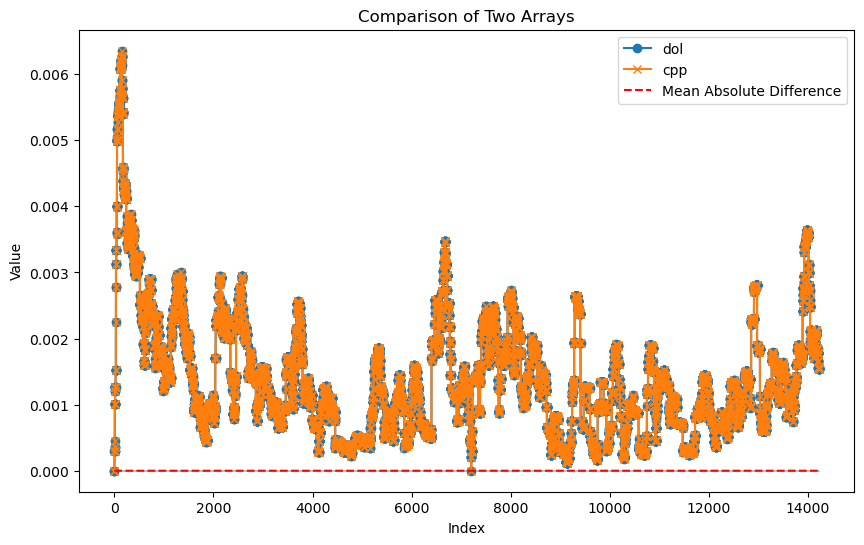

Mean of dol: 0.0013933484089848614, Standard Deviation: 0.0008786199625397245
Mean of cpp: 0.0013933453301195422, Standard Deviation: 0.0008786178163234752
Spearman Rank Correlation: 0.999999958748738
Pearson Correlation: 0.9999999996385828
max diff：8.464797812473765e-08


In [ ]:
# import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
def check_data_between(dol_frame,cpp_frame):
    array1 = np.nan_to_num(dol_frame[factor_names].values,0)
    array2 = np.nan_to_num(cpp_frame[factor_names].values,0)
    # 计算基本统计量
    mean1, std1 = np.mean(array1), np.std(array1)
    mean2, std2 = np.mean(array2), np.std(array2)
    
    # 计算排名一致性（使用Spearman等级相关系数）
    rank_correlation, _ = spearmanr(array1, array2)
    
    # 计算皮尔逊相关系数
    pearson_correlation, _ = pearsonr(array1, array2)
    
    # 计算绝对差异
    abs_diff = np.abs(array1 - array2)
    
    # 绘制折线图
    plt.figure(figsize=(10, 6))
    plt.plot(array1, label='dol', marker='o')
    plt.plot(array2, label='cpp', marker='x')
    
    # 绘制绝对差异分布
    plt.plot(abs_diff, color='r', linestyle='--', label='Mean Absolute Difference')
    plt.fill_between(np.arange(len(abs_diff)), abs_diff, color='gray', alpha=0.5)
    
    plt.title('Comparison of Two Arrays')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.show()
    
    # 打印统计结果
    print(f"Mean of dol: {mean1}, Standard Deviation: {std1}")
    print(f"Mean of cpp: {mean2}, Standard Deviation: {std2}")
    print(f"Spearman Rank Correlation: {rank_correlation}")
    print(f"Pearson Correlation: {pearson_correlation}")
    print(f"max diff：{max(abs_diff)}")
check_data_between(replayFactor,cpp_frame)

In [ ]:
target_columns = ["DateTime"]
target_columns.extend(["ask{}_p".format(i) for i in range(5)])
target_columns.extend(["ask{}_v".format(i) for i in range(5)])
target_columns.extend(["bid{}_p".format(i) for i in range(5)])
target_columns.extend(["bid{}_v".format(i) for i in range(5)])
target_columns
sub_tick_df = tick_df.select(target_columns)
sub_tick_df_dol = tick_df_dol.select(target_columns)
merge_df = sub_tick_df.join(sub_tick_df_dol, left_on = "DateTime", right_on = "DateTime")

for ridx, row in enumerate(merge_df.iter_rows(named = True)):
    if ridx<20:
        continue
    for col in target_columns:
        if col in ["DateTime"]:
            continue
        if not row[col] == row[col+"_right"]:
            print(row["DateTime"], col, row[col] , row[col+"_right"])



In [8]:
display(replayFactor.loc[:30])
display(cpp_frame.loc[:30])

,HTSCSecurityID,timestamp,FactorNSWBuyToVWapCorr
0,688012.SH,2024-06-12 09:30:01,0.000000
1,688012.SH,2024-06-12 09:30:02,0.000000
2,688012.SH,2024-06-12 09:30:03,0.000000
3,688012.SH,2024-06-12 09:30:04,0.000000
4,688012.SH,2024-06-12 09:30:05,0.000000
5,688012.SH,2024-06-12 09:30:06,0.000000
6,688012.SH,2024-06-12 09:30:07,0.000000
7,688012.SH,2024-06-12 09:30:08,0.000000
8,688012.SH,2024-06-12 09:30:09,0.000000
9,688012.SH,2024-06-12 09:30:10,0.000000


,FactorNSWBuyToVWapCorr,MDTime
0,0.0,20240612093001000
1,0.0,20240612093002000
2,0.0,20240612093003000
3,0.0,20240612093004000
4,0.0,20240612093005000
5,0.0,20240612093006000
6,0.0,20240612093007000
7,0.0,20240612093008000
8,0.0,20240612093009000
9,0.0,20240612093010000
